In [7]:
import pandas as pd
import numpy as np

In [8]:
df = pd.read_csv("WineDataset.csv")

In [9]:
def parse_price(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    if "per case" in s.lower() or "each" in s.lower():
        return np.nan  # exclude these
    s = s.replace("£", "").split()[0]
    try:
        return float(s)
    except:
        return np.nan

df["Price_num"] = df["Price"].apply(parse_price)


In [10]:
def parse_abv(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().replace("abv", "").replace("%", "").strip()
    try:
        return float(s)
    except:
        return np.nan

df["ABV_num"] = df["ABV"].apply(parse_abv)

In [11]:
def parse_capacity(x):
    if pd.isna(x):
        return np.nan

    s = str(x).upper().strip()

    # Remove obvious garbage
    if s in ["OUR", "NONE", "N/A", "UNKNOWN"]:
        return np.nan

    # Extract numeric part safely
    import re
    num = re.findall(r"\d+\.?\d*", s)
    if len(num) == 0:
        return np.nan
    num = float(num[0])

    # Normalise units
    if "CL" in s:
        return num * 10          # 75CL → 750 mL
    if "ML" in s:
        return num               # already mL
    if "LITRE" in s or "LTR" in s or "L" in s:
        return num * 1000        # 1.5L → 1500 mL

    # If unit missing but number looks like 75 → assume CL
    if num < 200:                # typical CL values
        return num * 10

    # If number looks like 750 → assume mL
    if 200 <= num <= 5000:
        return num

    return np.nan


In [12]:
df["Capacity_ml"] = df["Capacity"].apply(parse_capacity)


In [13]:
# --- has_appellation: missing = 0, present = 1 ---
df["has_appellation"] = df["Appellation"].notna().astype(int)

In [14]:
# --- is_blend: Secondary Grape Varieties missing = 0 (single), present = 1 (blend) ---
df["is_blend"] = df["Secondary Grape Varieties"].notna().astype(int)


In [15]:
df_model = df.dropna(subset=["Price_num", "ABV_num", "Capacity_ml"])

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
# Choose features (you can add more later)
feature_cols = ["ABV_num", "Capacity_ml", "has_appellation", "is_blend"]
X = df_model[feature_cols]
y = df_model["Price_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [18]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [19]:
# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [20]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} Results")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)
    print("-" * 30)

evaluate("Decision Tree", y_test, dt_pred)
evaluate("Random Forest", y_test, rf_pred)

Decision Tree Results
MAE: 16.269743852821872
RMSE: 29.915234234913047
R²: 0.13398691621714343
------------------------------
Random Forest Results
MAE: 15.997174475783993
RMSE: 29.665877815634982
R²: 0.14836393353158295
------------------------------


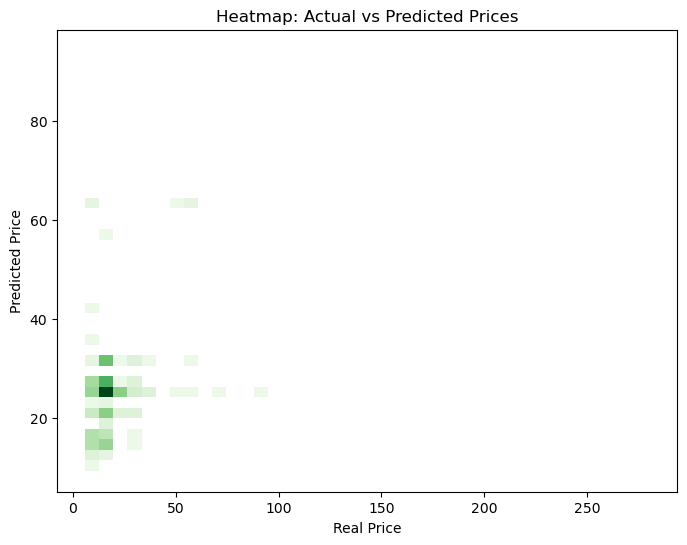

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.histplot(
    x=y_test,
    y=rf_pred,   # or dt_pred
    bins=40,
    pthresh=0.1,
    cmap="Greens"
)

plt.xlabel("Real Price")
plt.ylabel("Predicted Price")

plt.title("Heatmap: Actual vs Predicted Prices")
plt.show()


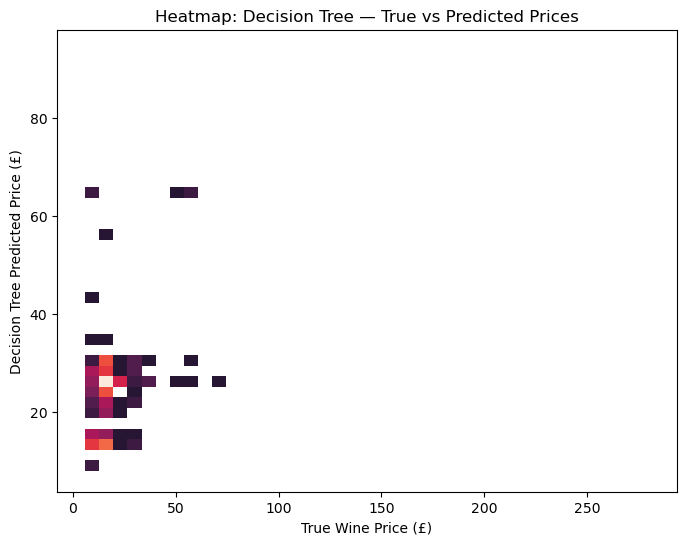

In [22]:
plt.figure(figsize=(8,6))
sns.histplot(
    x=y_test,
    y=dt_pred,
    bins=40,
    pthresh=0.1,
    cmap="rocket"
)

plt.xlabel("True Wine Price (£)")
plt.ylabel("Decision Tree Predicted Price (£)")
plt.title("Heatmap: Decision Tree — True vs Predicted Prices")
plt.show()


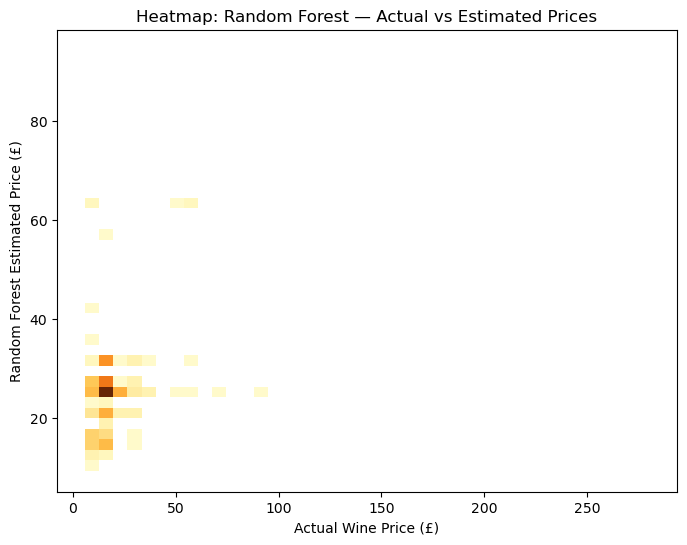

In [23]:
plt.figure(figsize=(8,6))
sns.histplot(
    x=y_test,
    y=rf_pred,
    bins=40,
    pthresh=0.1,
    cmap="YlOrBr"
)

plt.xlabel("Actual Wine Price (£)")
plt.ylabel("Random Forest Estimated Price (£)")
plt.title("Heatmap: Random Forest — Actual vs Estimated Prices")
plt.show()


In [24]:
# If Fairlearn is not installed, run this once:
!pip install fairlearn

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_validate, learning_curve
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from fairlearn.metrics import MetricFrame

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [47]:
# ---------------------------------------------------------
# CROSS-VALIDATION
# ---------------------------------------------------------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

cv_results = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        }
    )

    cv_results.append({
        "Model": model_name,
        "Mean CV MAE": -scores["test_MAE"].mean(),
        "Mean CV RMSE": -scores["test_RMSE"].mean(),
        "Mean CV R²": scores["test_R2"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Mean CV MAE,Mean CV RMSE,Mean CV R²
0,Decision Tree,17.179249,33.616918,0.073749
1,Random Forest,17.049617,33.418009,0.084500


In [48]:
# ---------------------------------------------------------
# TEST SET PERFORMANCE
# ---------------------------------------------------------

test_results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    test_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R²": r2_score(y_test, predictions)
    })

test_results_df = pd.DataFrame(test_results)

test_results_df

,Model,MAE,RMSE,R²
0,Decision Tree,16.269744,29.915234,0.133987
1,Random Forest,15.997174,29.665878,0.148364


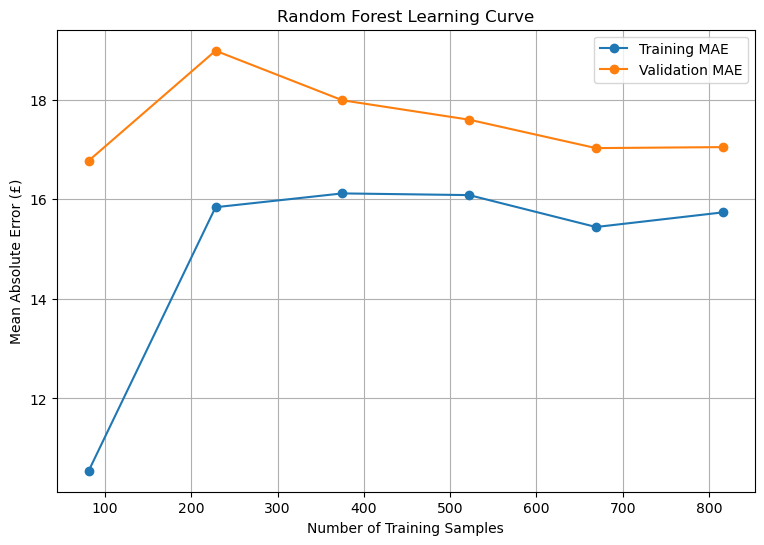

In [49]:
# ---------------------------------------------------------
# LEARNING CURVE - RANDOM FOREST
# ---------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

train_sizes, train_scores, validation_scores = learning_curve(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

train_mae = -train_scores.mean(axis=1)
validation_mae = -validation_scores.mean(axis=1)

train_std = train_scores.std(axis=1)
validation_std = validation_scores.std(axis=1)

plt.figure(figsize=(9, 6))

plt.plot(
    train_sizes,
    train_mae,
    marker="o",
    label="Training MAE"
)

plt.plot(
    train_sizes,
    validation_mae,
    marker="o",
    label="Validation MAE"
)

plt.xlabel("Number of Training Samples")
plt.ylabel("Mean Absolute Error (£)")
plt.title("Random Forest Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

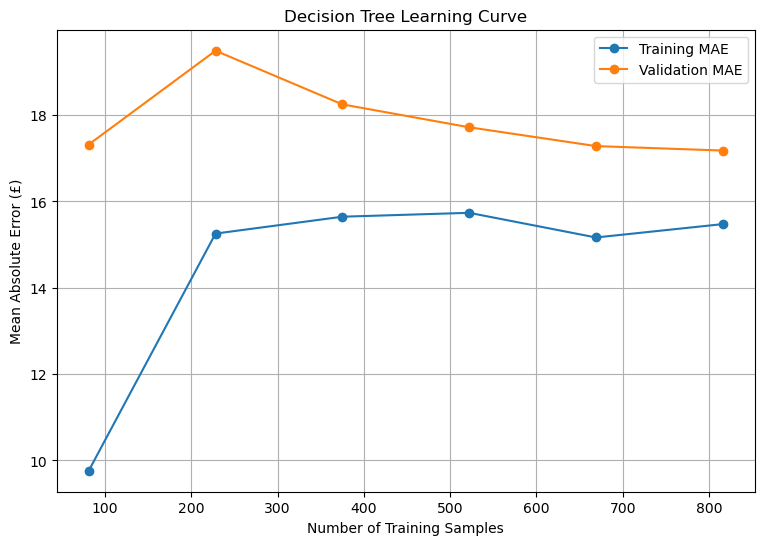

In [50]:
# ---------------------------------------------------------
# LEARNING CURVE - DECISION TREE
# ---------------------------------------------------------

dt_model = DecisionTreeRegressor(
    random_state=42
)

train_sizes_dt, train_scores_dt, validation_scores_dt = learning_curve(
    dt_model,
    X_train,
    y_train,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

train_mae_dt = -train_scores_dt.mean(axis=1)
validation_mae_dt = -validation_scores_dt.mean(axis=1)

plt.figure(figsize=(9, 6))

plt.plot(
    train_sizes_dt,
    train_mae_dt,
    marker="o",
    label="Training MAE"
)

plt.plot(
    train_sizes_dt,
    validation_mae_dt,
    marker="o",
    label="Validation MAE"
)

plt.xlabel("Number of Training Samples")
plt.ylabel("Mean Absolute Error (£)")
plt.title("Decision Tree Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

In [51]:
# ---------------------------------------------------------
# FAIRNESS / SUBGROUP ANALYSIS
# ---------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [36]:
%whos

Variable                Type                     Data/Info
----------------------------------------------------------
DecisionTreeRegressor   ABCMeta                  <class 'sklearn.tree._cla<...>s.DecisionTreeRegressor'>
KFold                   ABCMeta                  <class 'sklearn.model_selection._split.KFold'>
MetricFrame             type                     <class 'fairlearn.metrics<...>etric_frame.MetricFrame'>
RandomForestRegressor   ABCMeta                  <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
X                       DataFrame                      ABV_num  Capacity_m<...>\n[1276 rows x 4 columns]
X_test                  DataFrame                      ABV_num  Capacity_m<...>n\n[256 rows x 4 columns]
X_train                 DataFrame                      ABV_num  Capacity_m<...>\n[1020 rows x 4 columns]
cross_validate          function                 <function cross_validate at 0x15cfa5760>
cv                      KFold                    KFold(n_splits=5,

In [54]:
fairness_test = y_test.copy()

fairness_test["Prediction"] = rf_predictions
fairness_test["Actual"] = y_test.values

In [58]:
fairness_test = pd.DataFrame({
    "Type": df.loc[y_test.index, "Type"].to_numpy(),
    "Actual": y_test.to_numpy(),
    "Prediction": rf_predictions
}, index=y_test.index)

fairness_test = fairness_test[
    fairness_test["Type"].isin(["Red", "White", "Rosé"])
].copy()

fairness_test.head()

,Type,Actual,Prediction
101,Red,18.99,28.019781
51,Rosé,11.99,19.495621
76,White,29.99,42.294880
655,White,11.99,25.349718
433,Red,9.99,25.349718


In [59]:
# ---------------------------------------------------------
# FAIRLEARN METRIC FRAME
# ---------------------------------------------------------

metrics = {
    "MAE": mean_absolute_error,
    "RMSE": lambda y_true, y_pred:
        np.sqrt(mean_squared_error(y_true, y_pred))
}

metric_frame = MetricFrame(
    metrics=metrics,
    y_true=fairness_test["Actual"],
    y_pred=fairness_test["Prediction"],
    sensitive_features=fairness_test["Type"]
)

print("Overall performance:")
display(metric_frame.overall)

print("\nPerformance by wine type:")
display(metric_frame.by_group)

print("\nDifference between highest and lowest group:")
display(metric_frame.difference())

Overall performance:


MAE     16.021441
RMSE    29.717641
dtype: float64


Performance by wine type:


,MAE,RMSE
Type,,
Red,13.270036,19.022157
Rosé,29.026778,50.627141
White,15.921236,31.912385



Difference between highest and lowest group:


MAE     15.756742
RMSE    31.604984
dtype: float64

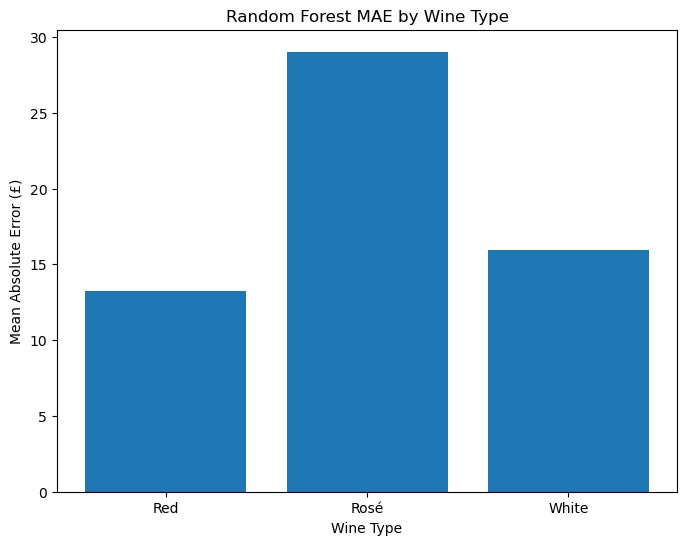

In [60]:
# ---------------------------------------------------------
# FAIRNESS VISUALISATION
# ---------------------------------------------------------

group_results = metric_frame.by_group.reset_index()

plt.figure(figsize=(8, 6))

plt.bar(
    group_results["Type"],
    group_results["MAE"]
)

plt.xlabel("Wine Type")
plt.ylabel("Mean Absolute Error (£)")
plt.title("Random Forest MAE by Wine Type")

plt.show()

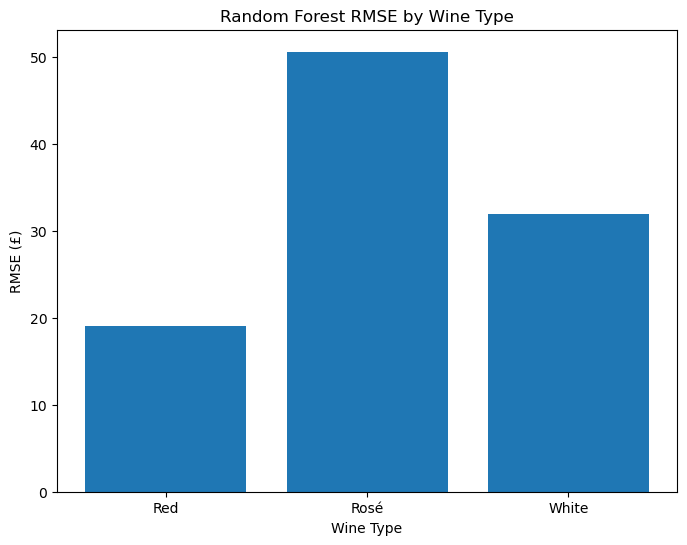

In [61]:
plt.figure(figsize=(8, 6))

plt.bar(
    group_results["Type"],
    group_results["RMSE"]
)

plt.xlabel("Wine Type")
plt.ylabel("RMSE (£)")
plt.title("Random Forest RMSE by Wine Type")

plt.show()

In [62]:
group_counts = (
    fairness_test["Type"]
    .value_counts()
    .rename_axis("Wine Type")
    .reset_index(name="Number of Test Samples")
)

group_counts

,Wine Type,Number of Test Samples
0,White,122
1,Red,109
2,Rosé,24


In [63]:
# ---------------------------------------------------------
# FINAL MODEL COMPARISON TABLE
# ---------------------------------------------------------

comparison = pd.merge(
    test_results_df,
    cv_results_df,
    on="Model",
    how="left",
    suffixes=("_Test", "_CV")
)

comparison

,Model,MAE,RMSE,R²,Mean CV MAE,Mean CV RMSE,Mean CV R²
0,Decision Tree,16.269744,29.915234,0.133987,17.179249,33.616918,0.073749
1,Random Forest,15.997174,29.665878,0.148364,17.049617,33.418009,0.084500


In [64]:
comparison.round(3)

,Model,MAE,RMSE,R²,Mean CV MAE,Mean CV RMSE,Mean CV R²
0,Decision Tree,16.270,29.915,0.134,17.179,33.617,0.074
1,Random Forest,15.997,29.666,0.148,17.050,33.418,0.084
